In [6]:
import torch

from keypoints import HandKeypointDetector
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [ ]:
model = HandKeypointDetector().to(device)
model.load_state_dict(torch.load("keypoints_checkpoints/keypoints_epoch62.pth", map_location=device, weights_only=True))


/home/mihai/Documents/Hand-Detector/venv311/lib/python3.11/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


<All keys matched successfully>

In [9]:
from pathlib import Path

import torch
from torch.utils.data import Dataset
from PIL import Image
import random

class YoloDataset(Dataset):
    def __init__(self, images_dir: Path, labels_dir: Path, transform=None):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transform = transform

        allowed_ext = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
        self.samples = []

        for image_path in self.images_dir.iterdir():
            if image_path.suffix.lower() not in allowed_ext:
                continue

            label_path = self.labels_dir / f"{image_path.stem}.txt"
            if label_path.exists():
                self.samples.append((image_path, label_path))

        if not self.samples:
            raise RuntimeError(f"Nu exista perechi imagine-label in {self.images_dir}")
        
    def __len__(self):
        return len(self.samples)
    
    def _read_label(self, label_path: Path):
        with open(label_path, 'r') as f:
            features = f.readline().strip().split(" ")

        # Ignorăm primele 5 valori (clasa și bbox). Luăm STRICT cele 63 de puncte cheie.
        handKeypoints = [float(point) for point in features[5:]]
        
        return torch.tensor(handKeypoints, dtype=torch.float32)
    
    def _cropImage(self, image, label):
        cropPadding = 0.05
        orig_w, orig_h = image.size

        # Eticheta conține DOAR keypoints acum, o clonăm
        keypoints = label.clone()
        
        if keypoints.numel() == 0:
            return image, label
            
        kps = keypoints.view(-1, 3) 
        
        # Detectăm dacă sunt în pixeli (>1) sau normalizate (<=1)
        if kps[:, 0].max() > 1.0 or kps[:, 1].max() > 1.0:
             xs_norm = kps[:, 0] / orig_w
             ys_norm = kps[:, 1] / orig_h
        else:
             xs_norm = kps[:, 0]
             ys_norm = kps[:, 1]

        # Calculăm marginile de crop dinamic din poziția punctelor cheie
        x_min = float(xs_norm.min()); y_min = float(ys_norm.min())
        x_max = float(xs_norm.max()); y_max = float(ys_norm.max())

        pad = cropPadding
        x_min_px = max(0, int((x_min - pad) * orig_w))
        y_min_px = max(0, int((y_min - pad) * orig_h))
        x_max_px = min(orig_w, int((x_max + pad) * orig_w))
        y_max_px = min(orig_h, int((y_max + pad) * orig_h))

        crop_w = max(1, x_max_px - x_min_px)
        crop_h = max(1, y_max_px - y_min_px)

        croppedImage = image.crop((x_min_px, y_min_px, x_max_px, y_max_px))

        # Ajustăm keypoints relativ la noua imagine decupată
        if kps[:, 0].max() > 1.0 or kps[:, 1].max() > 1.0:
            kps[:, 0] = (kps[:, 0] - x_min_px) / crop_w
            kps[:, 1] = (kps[:, 1] - y_min_px) / crop_h
        else:
            kps[:, 0] = (kps[:, 0] * orig_w - x_min_px) / crop_w
            kps[:, 1] = (kps[:, 1] * orig_h - y_min_px) / crop_h
            
        kps[:, 0:2] = kps[:, 0:2].clamp(0.0, 1.0)
        
        return croppedImage, kps.view(-1)
    
    def __getitem__(self, idx):
        image_path, label_path = self.samples[idx]

        label = self._read_label(label_path)
        image = Image.open(image_path).convert("RGB")
        
        cropped_image, cropped_label = self._cropImage(image, label)

        if self.transform is not None:
            cropped_image = self.transform(cropped_image)

        # Returnăm direct, fără să mai tăiem nimic la final!
        return cropped_image, cropped_label
        
    
from torchvision import transforms

image_size = 256


transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Face valorile [-2, 2]
])

trainDataset = YoloDataset("dataset/hand-keypoints/images/train",
                        "dataset/hand-keypoints/labels/train", transform=transform)
                        
testDataset = YoloDataset("dataset/hand-keypoints/images/val",
                        "dataset/hand-keypoints/labels/val", transform=transform)

print(f"Numar de imagini pentru antrenare: {len(trainDataset)}")
print(f"Numar de imagini pentru testare: {len(testDataset)}")

print(f"shape label: {trainDataset[0][1].shape}")

Numar de imagini pentru antrenare: 18776
Numar de imagini pentru testare: 7992
shape label: torch.Size([63])


In [15]:
def epe(preds, targets):
    # preds și targets sunt tensori de forma (N, 63) unde N e batch size-ul
    preds = preds.view(-1, 21, 3)  # Reshape la (N, 21, 3)
    targets = targets.view(-1, 21, 3)

    # Calculăm distanța euclideană pentru fiecare punct cheie
    dists = torch.norm(preds[:, :, :2] - targets[:, :, :2], dim=2)  # Doar coordonatele x,y

    # Media distanțelor pentru fiecare imagine din batch
    epe_per_image = dists.mean(dim=1)  # Media pe cele 21 de puncte cheie

    return epe_per_image.mean().item()  # Media pe întreg batch-ul

def pke(preds, targets, threshold=0.05):
    # preds și targets sunt tensori de forma (N, 63) unde N e batch size-ul
    preds = preds.view(-1, 21, 3)  # Reshape la (N, 21, 3)
    targets = targets.view(-1, 21, 3)

    # Calculăm distanța euclideană pentru fiecare punct cheie
    dists = torch.norm(preds[:, :, :2] - targets[:, :, :2], dim=2)  # Doar coordonatele x,y

    # Contăm câte puncte cheie sunt corecte (distanța < threshold)
    correct_keypoints = (dists < threshold).sum(dim=1)  # Număr de puncte corecte per imagine

    # Media procentului de puncte corecte pentru fiecare imagine din batch
    pke_per_image = correct_keypoints / 21.0  # Procentaj pe cele 21 de puncte cheie

    return pke_per_image.mean().item()  # Media pe întreg batch-ul

Media EPE: 0.1642
Media timp: 13.6077
Media PKE: 0.5476


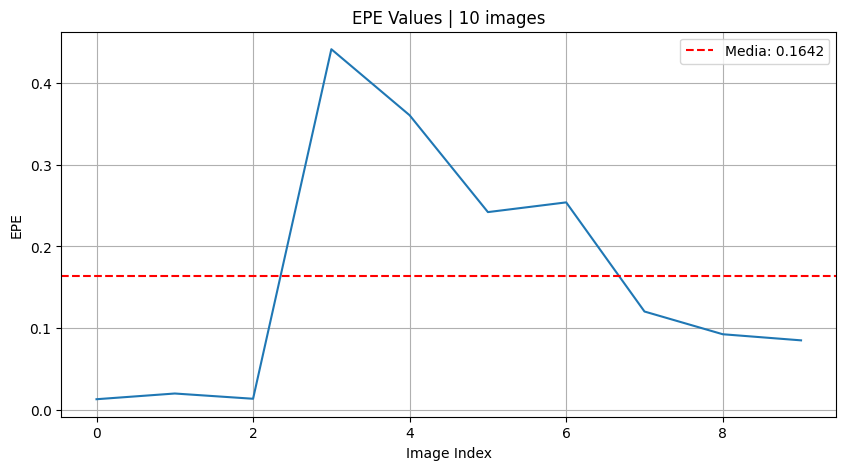

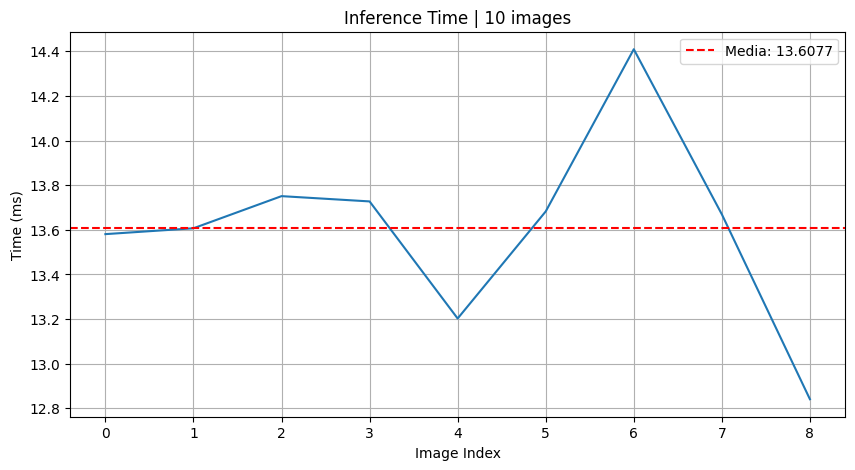

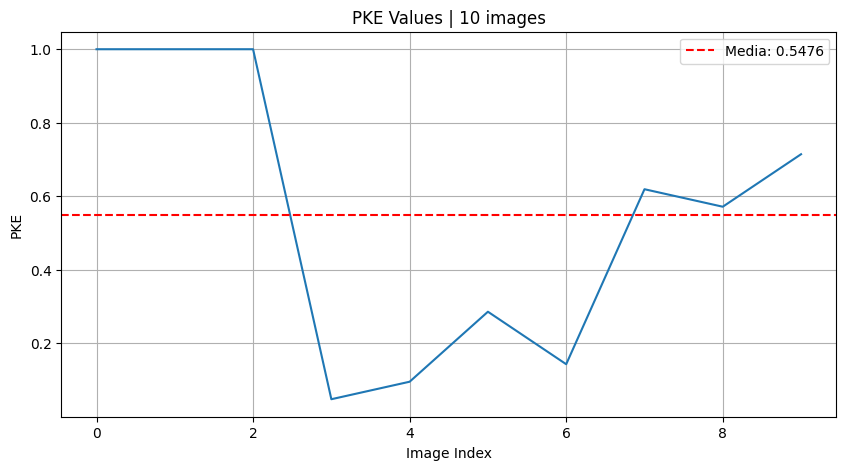

Media EPE: 0.1625
Media timp: 13.4429
Media PKE: 0.5643


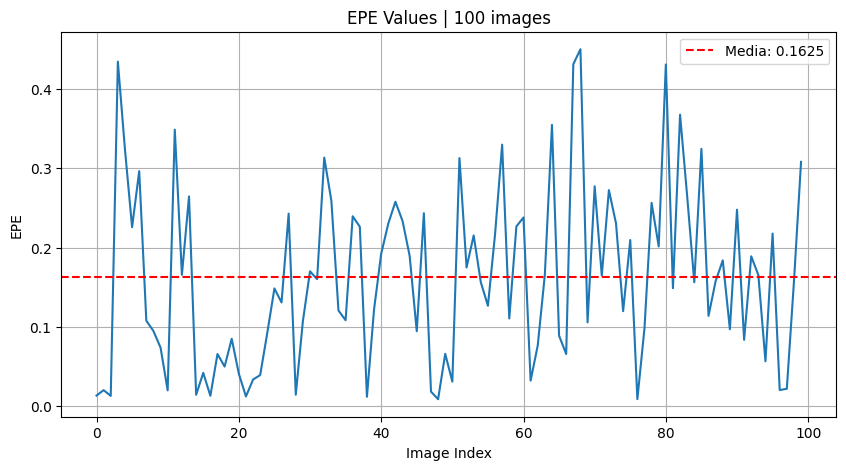

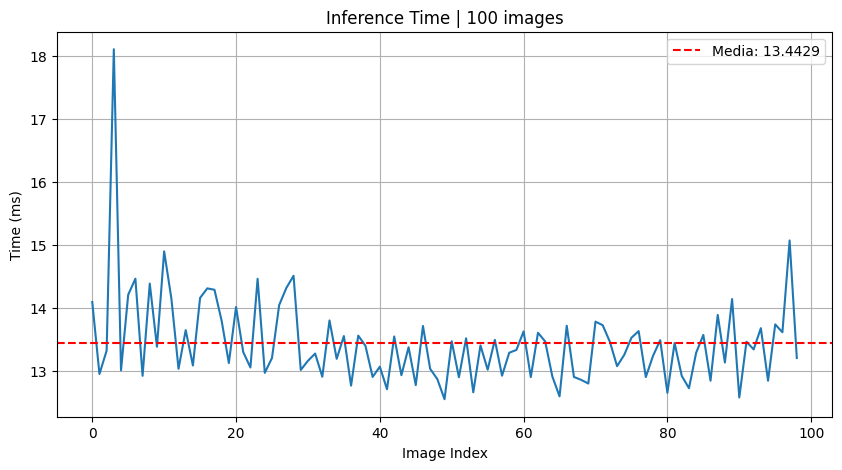

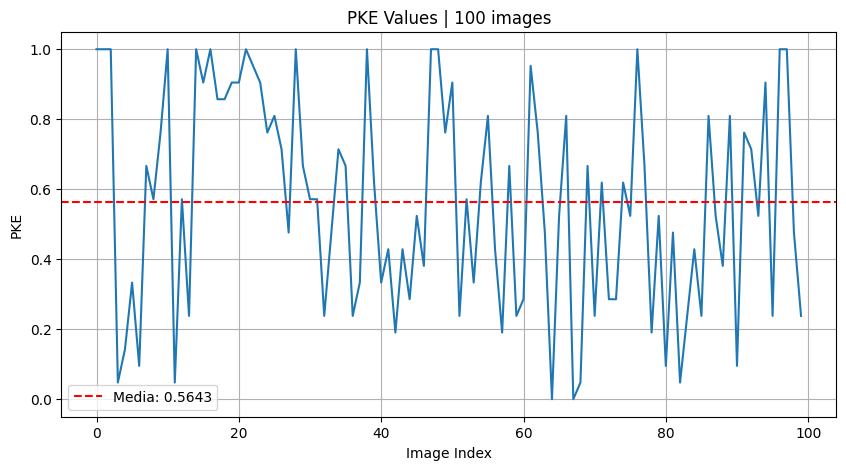

Media EPE: 0.1727
Media timp: 13.3449
Media PKE: 0.5343


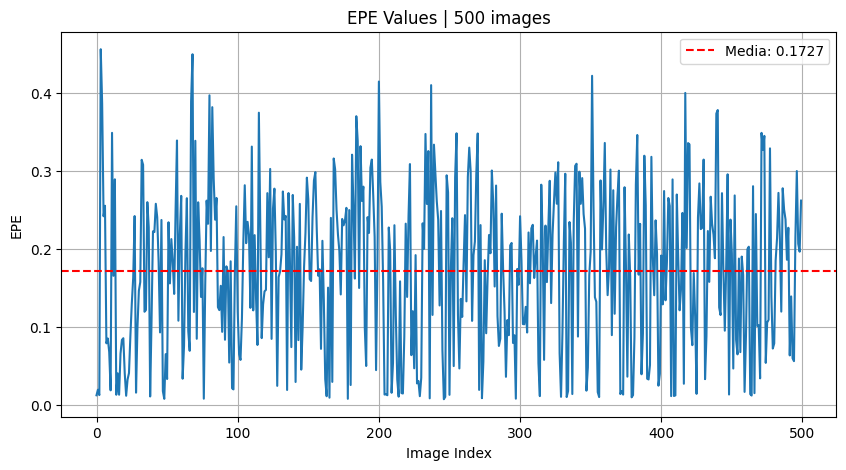

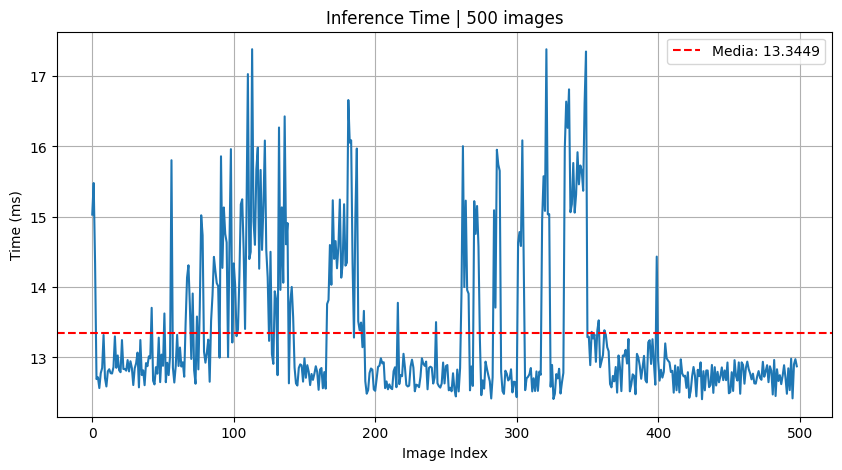

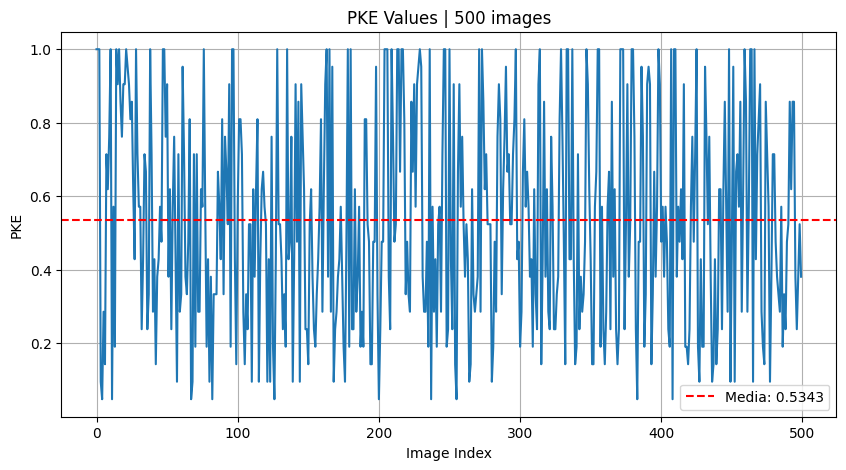

Media EPE: 0.1541
Media timp: 12.3973
Media PKE: 0.6188


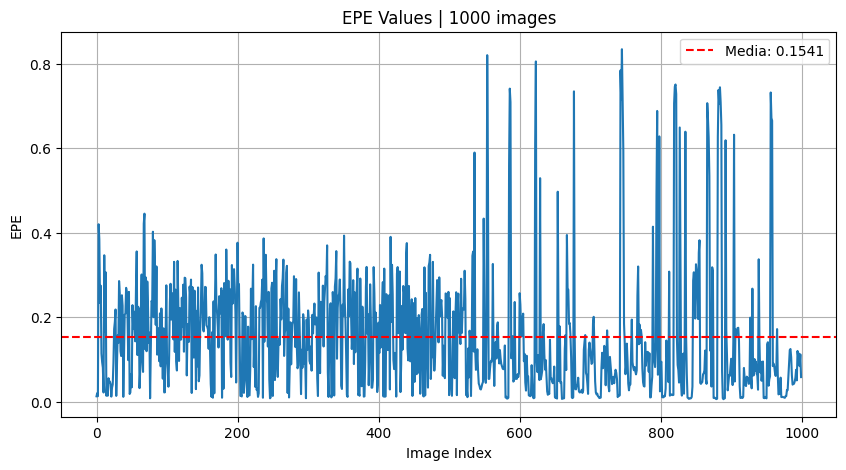

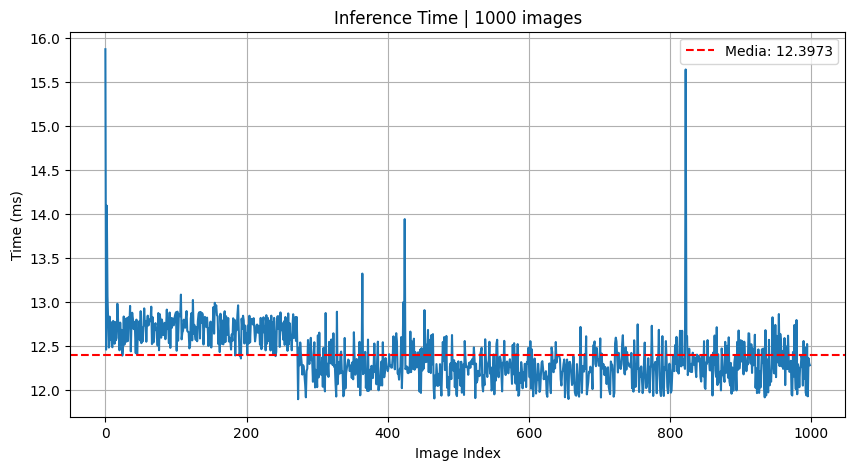

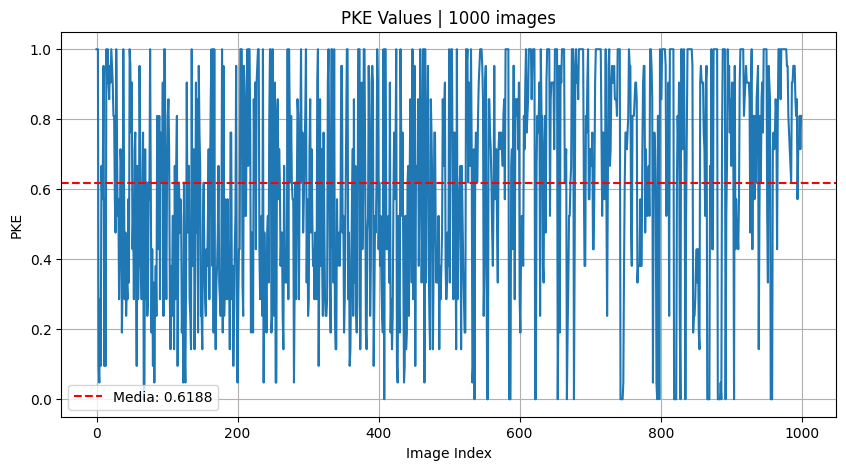

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_data(values, title, xlabel, ylabel, mean_value=None, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(values, marker='')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    if mean_value is not None:
        plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Media: {mean_value:.4f}')
        plt.legend()

    if save_path:
        plt.savefig(save_path)
    plt.show()
    

# randomIndex = random.randint(0, len(testDataset) - 1)
# img_tensor, label_tensor = testDataset[randomIndex]

data_nums= [10, 100, 500, 1000]

for data_num in data_nums:

    epe_values = np.zeros(data_num)
    pke_values = np.zeros(data_num)
    time_values = np.zeros(data_num)

    for index in range(data_num):
        
        img_tensor, label_tensor = testDataset[index]
        with torch.no_grad():
            start_time = torch.cuda.Event(enable_timing=True)
            start_time.record()
            pred = model(img_tensor.unsqueeze(0).to(device))
            end_time = torch.cuda.Event(enable_timing=True)
            end_time.record()

            torch.cuda.synchronize()
            delta_time = start_time.elapsed_time(end_time)  # Timpul în milisecunde
            time_values[index] = delta_time

        img = img_tensor.permute(1, 2, 0).cpu().numpy()
        h, w, _ = img.shape

        # Predicted keypoints from heatmaps (argmax)
        hmaps = pred.squeeze(0).cpu()  # (num_kp, Hm, Wm)
        num_kp, Hm, Wm = hmaps.shape


        pred_kps = []
        for i in range(num_kp):
            hm = hmaps[i].detach().cpu().numpy()
            idx = int(hm.argmax())
            ym = idx // Wm
            xm = idx % Wm
            x_norm = xm / Wm
            y_norm = ym / Hm
            pred_kps.extend([x_norm, y_norm, 2.0])

        pred_tensor = torch.tensor(pred_kps, dtype=label_tensor.dtype).unsqueeze(0)
        epe_value = epe(pred_tensor, label_tensor.unsqueeze(0))
        pke_value = pke(pred_tensor, label_tensor.unsqueeze(0), threshold=0.1)
        epe_values[index] = epe_value
        # print(f"EPE pentru imaginea curentă: {epe_value:.4f}")
        pke_values[index] = pke_value

    time_values = time_values[1:] 

    epe_mean = epe_values.mean()
    time_mean = time_values.mean()
    pke_mean = pke_values.mean()
    print(f"Media EPE: {epe_mean:.4f}")
    print(f"Media timp: {time_mean:.4f}")
    print(f"Media PKE: {pke_mean:.4f}")
    plot_data(epe_values, f"EPE Values | {data_num} images", "Image Index", "EPE", mean_value=epe_mean, save_path=f"diagrams/epe_values_{data_num}_images.png")
    plot_data(time_values, f"Inference Time | {data_num} images", "Image Index", "Time (ms)", mean_value=time_mean, save_path=f"diagrams/time_values_{data_num}_images.png")
    plot_data(pke_values, f"PKE Values | {data_num} images", "Image Index", "PKE", mean_value=pke_mean, save_path=f"diagrams/pke_values_{data_num}_images.png")